<!-- VISUALIZATION -->
<!-- # Delhi Metro Project -->

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("delhi_metro_cleaned.csv")

line_count = df.groupby('metro_line')['station_name'].count().reset_index()
line_count.columns = ['metro_line', 'station_count']
line_count = line_count.sort_values('station_count', ascending=False)

year_count = df.groupby('opened_year')['station_name'].count().reset_index()
year_count.columns = ['opened_year', 'stations_opened']
year_count = year_count.dropna()

pivot1 = pd.pivot_table(df, values='station_name',
                        index='metro_line', columns='layout',
                        aggfunc='count', fill_value=0)

colors = ['#378ADD','#D4537E','#EF9F27','#7F77DD','#E24B4A',
          '#993556','#1D9E75','#639922','#888780','#EF9F27',
          '#378ADD','#888780','#639922']

print("✅ Data ready for plots!")

✅ Data ready for plots!


C:\Users\shubh\AppData\Local\Temp\ipykernel_14840\3902783652.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=line_count, x='station_count', y='metro_line',


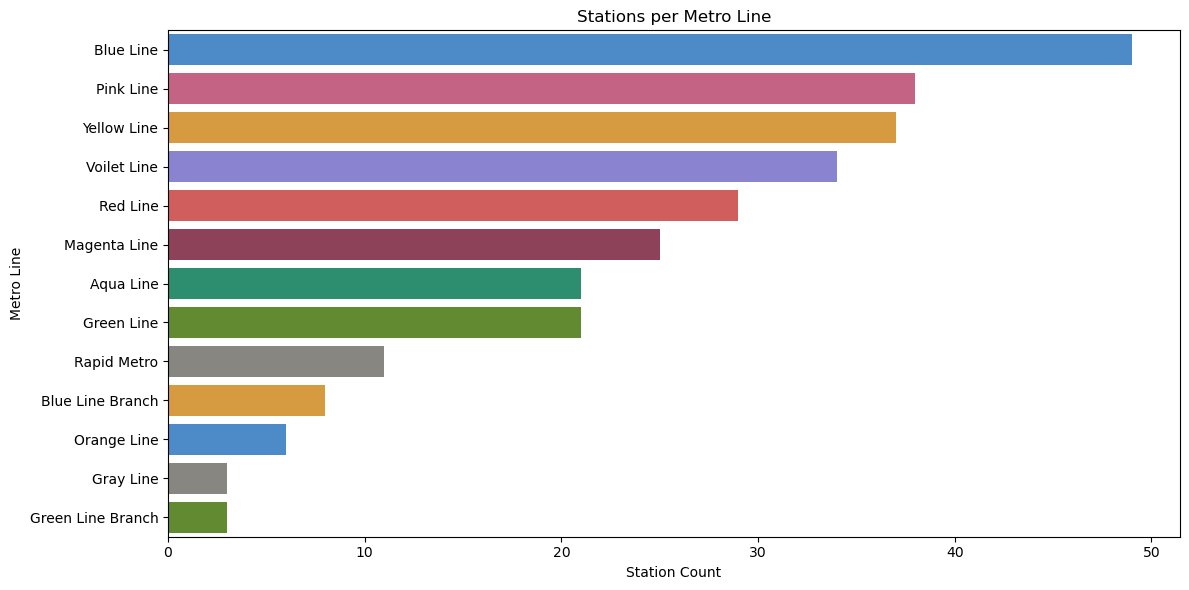

In [3]:
plt.figure(figsize=(12, 6))
sns.barplot(data=line_count, x='station_count', y='metro_line',
            palette=colors[:len(line_count)])
plt.title("Stations per Metro Line")
plt.xlabel("Station Count")
plt.ylabel("Metro Line")
plt.tight_layout()
plt.savefig("01_stations_per_line.png")
plt.show()

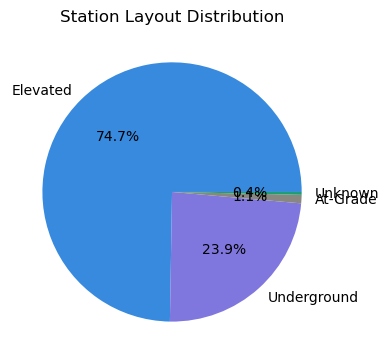

In [7]:
plt.figure(figsize=(4, 4))
layout_val = df['layout'].value_counts()
colors_pie = ['#378ADD', '#7F77DD', '#888780', '#1D9E75']
plt.pie(layout_val, labels=layout_val.index, autopct='%1.1f%%',
        colors=colors_pie[:len(layout_val)])
plt.title("Station Layout Distribution")
plt.tight_layout()
plt.savefig("02_layout_pie.png")
plt.show()

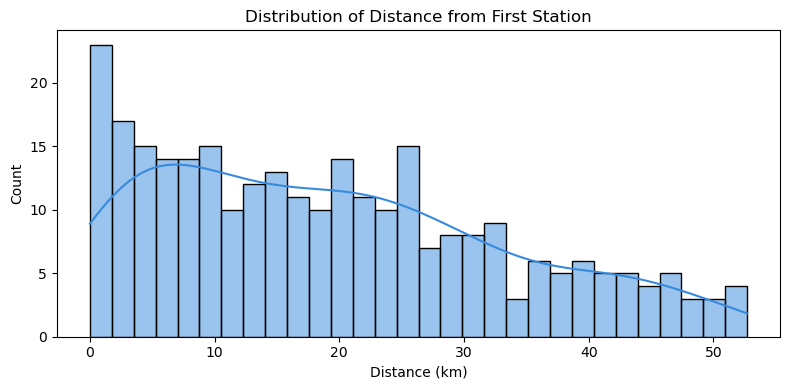

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['dist_km'], bins=30, kde=True, color='#378ADD')
plt.title("Distribution of Distance from First Station")
plt.xlabel("Distance (km)")
plt.tight_layout()
plt.savefig("03_dist_histogram.png")
plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_14840\1069896195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='metro_line', y='dist_km', palette='Set2')


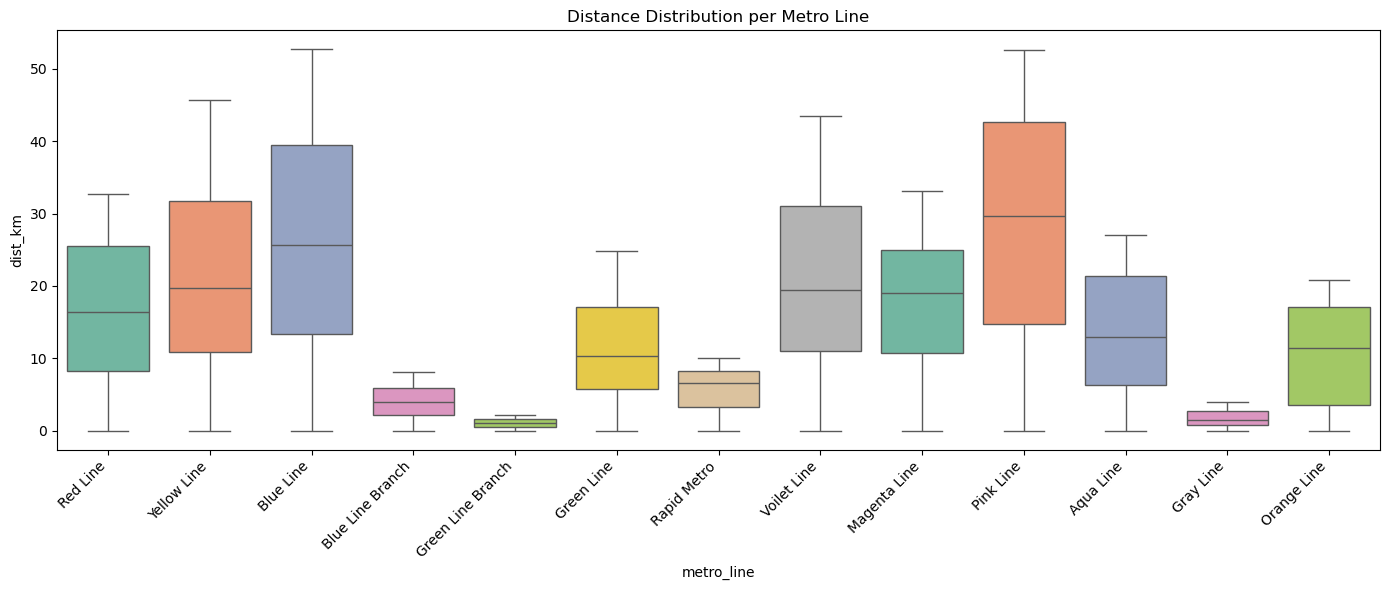

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='metro_line', y='dist_km', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Distance Distribution per Metro Line")
plt.tight_layout()
plt.savefig("04_dist_boxplot.png")
plt.show()

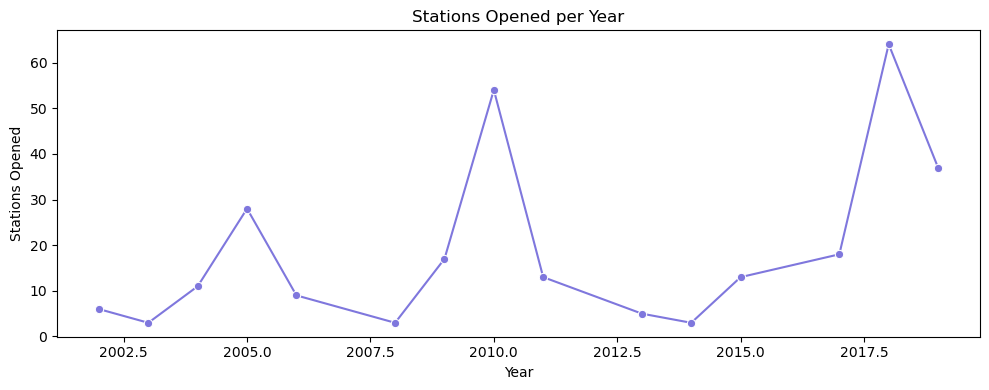

In [9]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=year_count, x='opened_year', y='stations_opened',
             marker='o', color='#7F77DD')
plt.title("Stations Opened per Year")
plt.xlabel("Year")
plt.ylabel("Stations Opened")
plt.tight_layout()
plt.savefig("05_stations_per_year.png")
plt.show()

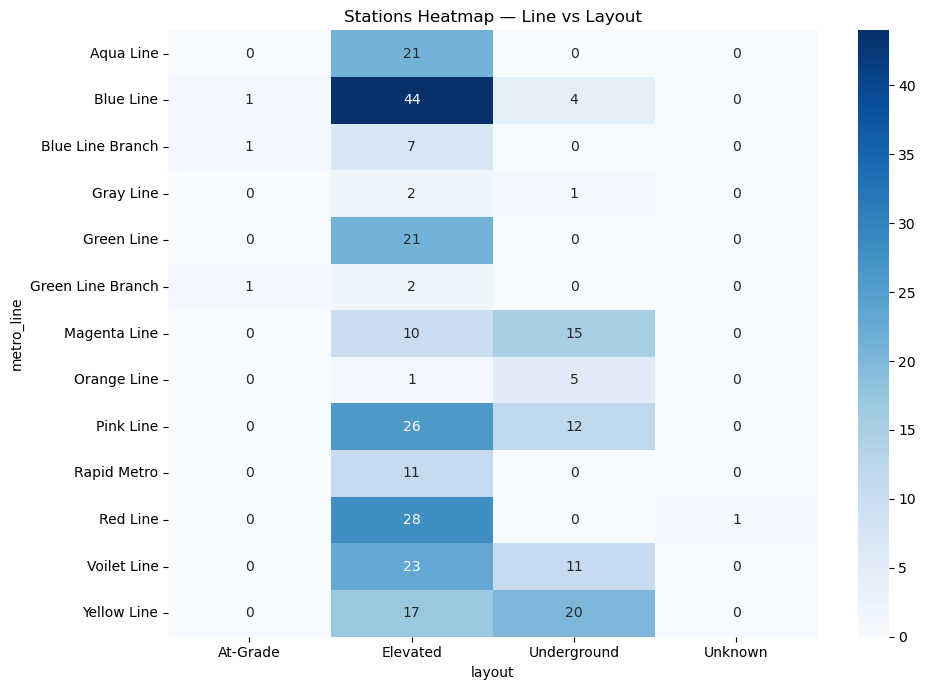

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(pivot1, annot=True, fmt='d', cmap='Blues')
plt.title("Stations Heatmap — Line vs Layout")
plt.tight_layout()
plt.savefig("06_heatmap.png")
plt.show()

C:\Users\shubh\AppData\Local\Temp\ipykernel_14840\3947765837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='layout', palette='pastel',


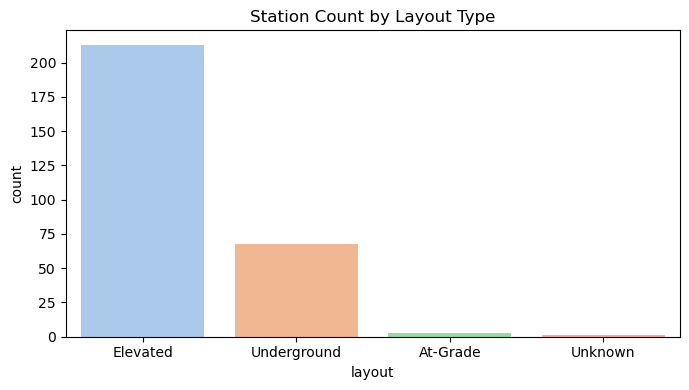

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='layout', palette='pastel',
              order=df['layout'].value_counts().index)
plt.title("Station Count by Layout Type")
plt.tight_layout()
plt.savefig("07_layout_countplot.png")
plt.show()

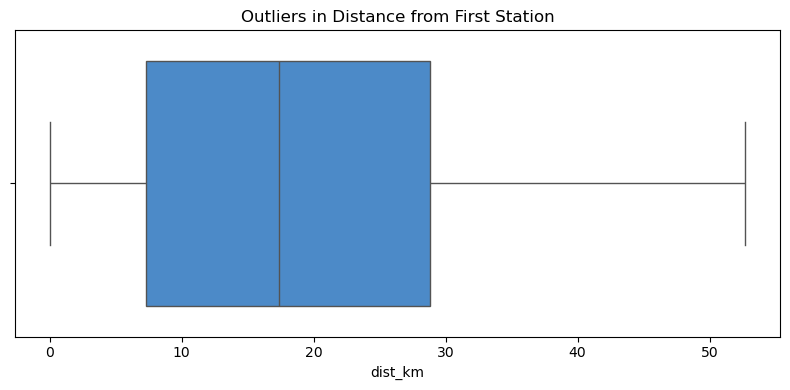

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['dist_km'], color='#378ADD')
plt.title("Outliers in Distance from First Station")
plt.tight_layout()
plt.savefig("08_outlier_boxplot.png")
plt.show()